**Import required libraries**

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

**Pandas** is used to load and manipulate the dataset.     
**NumPy** performs numerical computations.       
**Matplotlib** and **Seaborn** create graphs and visualizations.   
**Scikit-learn** provides preprocessing tools, machine learning algorithms, and evaluation metrics.  
**Joblib** saves the trained model for future use without retraining.

**Load the Dataset**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/House_Price_Prediction/Housing.csv")


This dataset provides comprehensive information for house price prediction, with 13 column names:

**Price:** The price of the house.   
**Area:** The total area of the house in square feet.    
**Bedrooms:** The number of bedrooms in the house.    
**Bathrooms:** The number of bathrooms in the house.    
**Stories:** The number of stories in the house.    
**Mainroad:** Whether the house is connected to the main road (Yes/No).     
**Guestroom:** Whether the house has a guest room (Yes/No).    
**Basement:** Whether the house has a basement (Yes/No).   
**Hot water heating:** Whether the house has a hot water heating system (Yes/No).  
**Airconditioning:** Whether the house has an air conditioning system (Yes/No).      
**Parking:** The number of parking spaces available within the house.
**Prefarea:** Whether the house is located in a preferred area (Yes/No).
**Furnishing status:** The furnishing status of the house (Fully Furnished, Semi-Furnished, Unfurnished).

Analyze the dataset through its summary

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [5]:
df.shape

(545, 13)

## **Dataset Overview**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [9]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [10]:
headers = ['price', 'area', 'bedrooms', 'bathrooms', 'stories',
           'mainroad', 'guestroom', 'basement', 'hotwaterheating',
           'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [11]:
for column in headers:
  df[column].replace(np.nan,"?",inplace=True)

df.head(10)

/tmp/ipykernel_1611/2162000606.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].replace(np.nan,"?",inplace=True)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## **Data Cleaning and Feature Engineering**

In [12]:
for column in headers:
  print(f"No.of Null values in column {column}:{df[column].isnull().sum()}\n")

No.of Null values in column price:0

No.of Null values in column area:0

No.of Null values in column bedrooms:0

No.of Null values in column bathrooms:0

No.of Null values in column stories:0

No.of Null values in column mainroad:0

No.of Null values in column guestroom:0

No.of Null values in column basement:0

No.of Null values in column hotwaterheating:0

No.of Null values in column airconditioning:0

No.of Null values in column parking:0

No.of Null values in column prefarea:0

No.of Null values in column furnishingstatus:0



Here, we can see that there are no null values in this data.

In [13]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


Here, we can see that there are no duplicate values in this data.

In [14]:
df = df.drop('prefarea', axis=1)

Column "Perfarea" has been dropped as it would no longer help in further analysis

In [15]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']


Identifies all categorical columns and displays the unique values present in each one.

In [16]:
categorical_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
]

categorical_columns

['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning']

In [17]:
for column in categorical_columns:
    df[column] = (
        df[column]
        .str.strip()      # Remove extra spaces
        .str.lower()      # Convert to lowercase
    )

Before mapping, clean the text because as Python is case-sensitive.

In [18]:
for column in categorical_columns:
    df[column] = df[column].map({
        "yes": 1,
        "no": 0
    })

Replaces each categorical value with its corresponding numerical value. This technique is called Label Mapping or Binary Encoding

In [20]:
df.nunique()

,0
price,219
area,284
bedrooms,6
bathrooms,4
stories,4
mainroad,2
guestroom,2
basement,2
hotwaterheating,2
airconditioning,2


Number of unique values present in each column

In [21]:

# ONE-HOT ENCODING

df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True,
    dtype=int
)

The furnishingstatus column contains three categories:

*   furnished
*   semi-furnished
*   unfurnished


Unlike binary columns, these categories cannot simply be mapped to numbers because doing so would incorrectly imply an order (for example, furnished > semi-furnished > unfurnished).

Instead, we use **One-Hot Encoding**, which creates separate binary columns for each category.

In [23]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [24]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


### **Exploratory Data Analysis(EDA)**

In [25]:

correlation_matrix = df.corr()

correlation_matrix

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.063656,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.006156,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.050040,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.029834,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,-0.003648,-0.082972
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.011450,-0.133123
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.005821,-0.099023
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.050284,-0.117935
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,0.063819,-0.059194
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,-0.053179,-0.094086


Calculates the **Pearson Correlation Coefficient** between every pair of numerical features.      
Correlation values range from -1 to +1.                      
Here,we just see the numerical values and its hard to find out and go through each numeric value ,hence we will visualize it for better insights via Heatmap

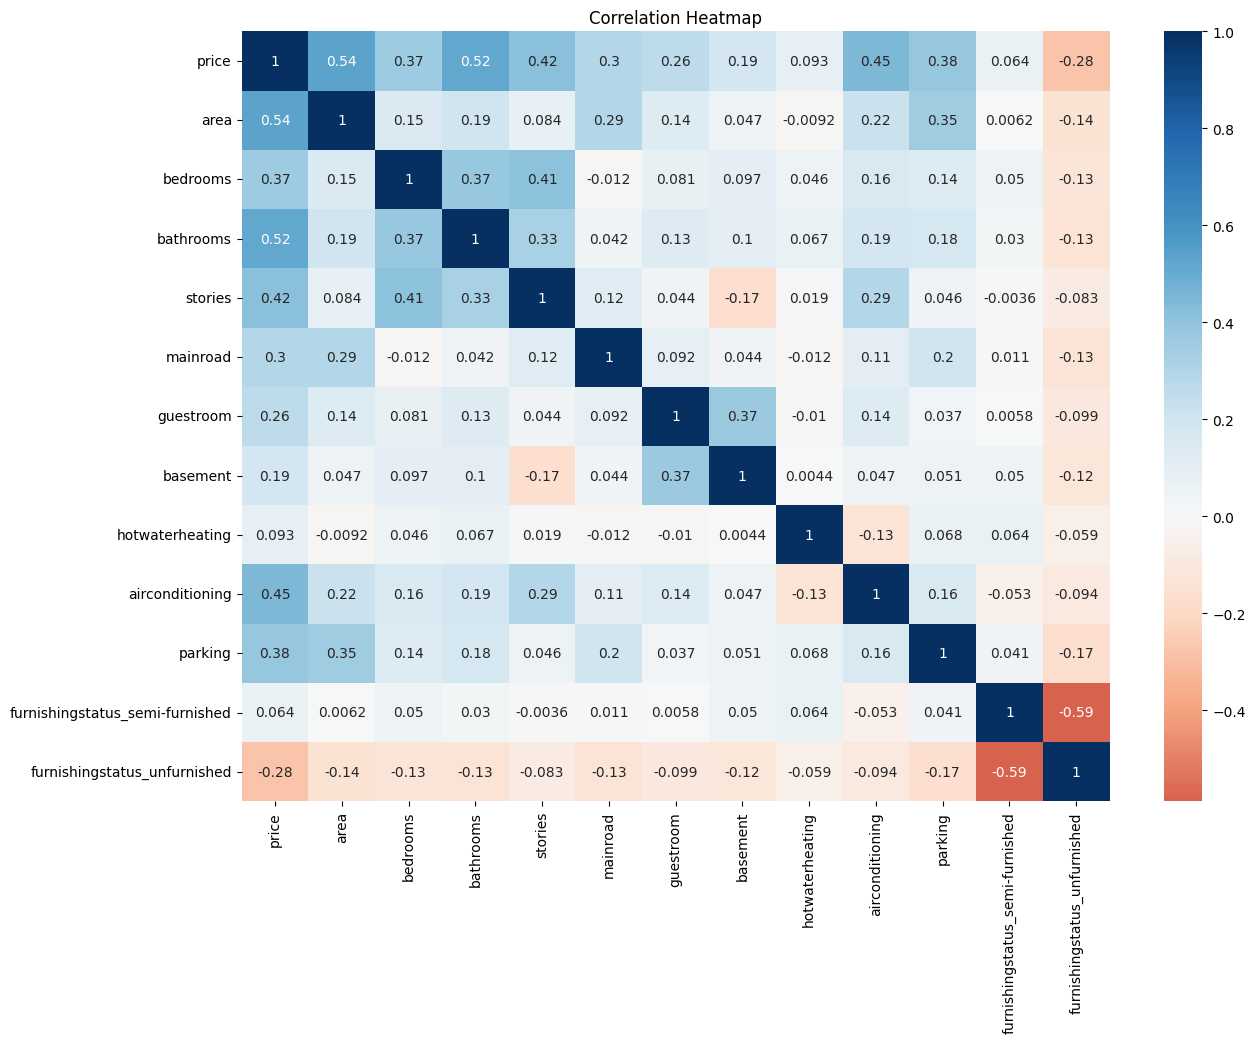

In [48]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

This visualization helps quickly identify which variables are strongly related to house prices.

In [49]:

correlation_with_price = (
    df.corr()["price"]
    .sort_values(ascending=False)
)

correlation_with_price

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
mainroad,0.296898
guestroom,0.255517
basement,0.187057


Instead of looking at correlations between every feature, we now focus only on the target variable (price).    
Typically, features such as:
*   Area
*   Bathrooms
*   Air Conditioning
*   Stories

shows stronger positive correlations with the price



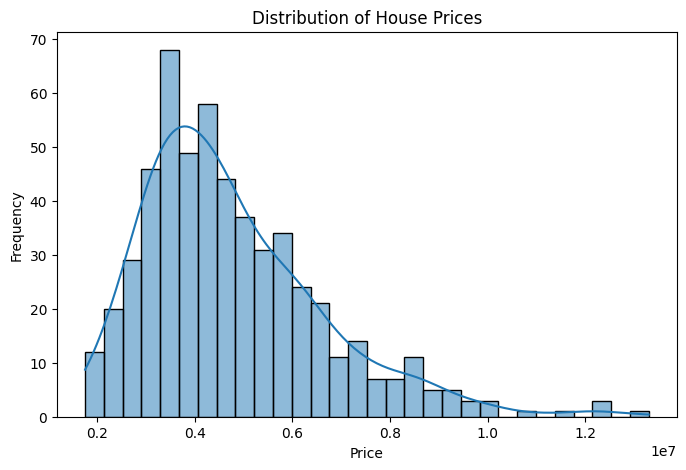

In [50]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

The histogram shows that most houses are priced between ₹30-60 lakhs, with the highest concentration around ₹35-45 lakhs. The distribution is positively (right) skewed, indicating that only a few houses have very high prices. The 1e7 displayed on the x-axis represents scientific notation, meaning the axis values are multiplied by 10,000,000 (e.g., 0.4 = ₹4,000,000 = ₹40 lakhs, 1.0 = ₹10,000,000 = ₹1 crore).

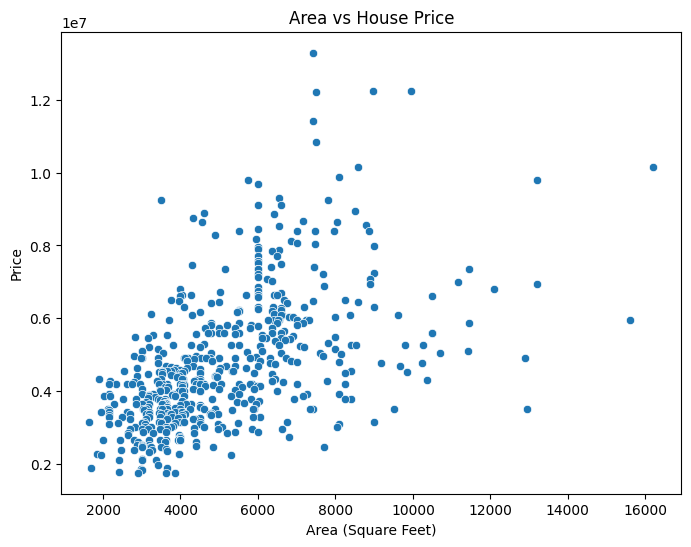

In [51]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="area",
    y="price"
)

plt.title("Area vs House Price")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Price")

plt.show()

This scatter plot indicates a moderate to strong positive relationship between the house area and price, meaning that as the area increases, the house price generally increases. The spread of points suggests that while area is an important predictor, other features also contribute to determining the final house price

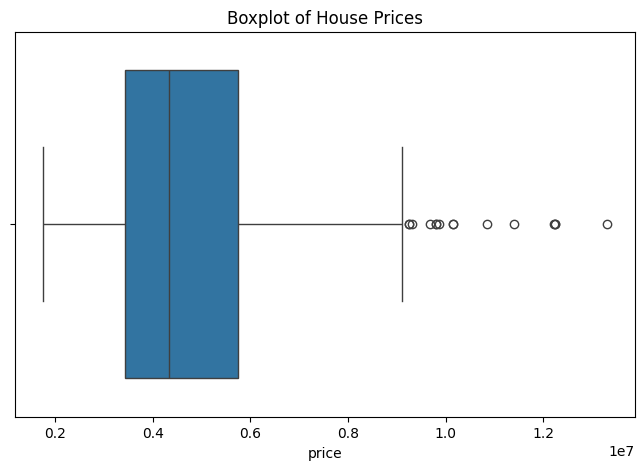

In [53]:

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["price"]
)

plt.title("Boxplot of House Prices")

plt.show()

The boxplot shows that most house prices are concentrated between ₹35-60 lakhs, with a median price of approximately ₹45 lakhs. The points beyond the upper whisker represent outliers, indicating a few exceptionally expensive houses that are significantly higher than the majority of the properties.

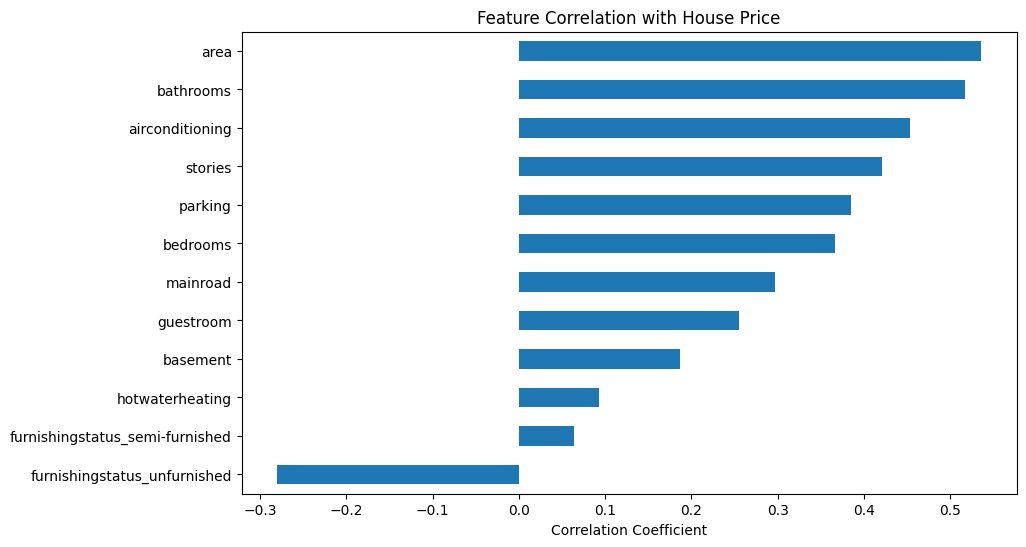

In [54]:

plt.figure(figsize=(10, 6))

correlation_with_price.drop("price").sort_values().plot(kind="barh")

plt.title("Feature Correlation with House Price")
plt.xlabel("Correlation Coefficient")

plt.show()

 Features such as area and number of bathrooms have the strongest positive correlation with house price, indicating they are the most influential features. In contrast, unfurnished houses have a negative correlation, suggesting they tend to have lower prices.

## **Preparing Data for Model Training**

In [55]:
X = df.drop("price", axis=1)
y = df["price"]

Remove the price column from the dataset to create the feature matrix X.

The price column is stored separately in y, which serves as the target variable for prediction.

In [56]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,0
3,7500,4,2,2,1,0,1,0,1,3,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,0


In [57]:
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

test_size=0.20 reserves 20% of the dataset for testing.  
random_state=42 ensures that the data is split in the same way every time the code is executed, making the results reproducible.

In [59]:

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (436, 12)
X_test Shape  : (109, 12)
y_train Shape : (436,)
y_test Shape  : (109,)


This step confirms that the dataset has been split correctly

## **Model Building using Linear Regression**

In [60]:
model = LinearRegression()

We initialize the Linear Regression model using Scikit-learn.

In [61]:
model.fit(X_train, y_train)

LinearRegression()

During training, the model learns the relationship between the input features (X_train) and the target variable (y_train) by finding the best-fit linear equation that minimizes the prediction error.

After this step, the model is ready to predict house prices for new or unseen data.

In [62]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,area,2.528005e+02
1,bedrooms,9.778690e+04
2,bathrooms,1.055412e+06
3,stories,4.037252e+05
4,mainroad,4.939342e+05
5,guestroom,2.778423e+05
6,basement,4.867107e+05
7,hotwaterheating,6.296456e+05
8,airconditioning,7.960461e+05
9,parking,2.279892e+05


The magnitude of the coefficient indicates how strongly the feature influences the prediction.

In [63]:
print("Intercept:", model.intercept_)

Intercept: 169586.7352062771


The intercept represents the predicted house price when all input features are zero.

## **Make Predictions**

In [64]:
y_pred = model.predict(X_test)

After training, the model is used to predict house prices for the unseen test dataset. These predictions are then compared with the actual prices to evaluate model performance.

In [65]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.258926e+06
1,6650000,6.718131e+06
2,3710000,3.206391e+06
3,6440000,4.746637e+06
4,2800000,3.417109e+06
5,4900000,3.688533e+06
6,5250000,5.821904e+06
7,4543000,5.998971e+06
8,2450000,2.722897e+06
9,3353000,2.604646e+06


Comparing the actual and predicted prices helps us understand how closely the model's predictions match the real house prices.

## **Model Evaluation**

In [66]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 988116.16
Mean Squared Error (MSE): 1837637189871.70
Root Mean Squared Error (RMSE): 1355594.77
R² Score: 0.6364


A lower MAE, MSE, and RMSE indicate better prediction accuracy, while an R² score closer to 1 indicates that the model explains most of the variation in house prices.

| Metric       |     Your Result | Interpretation                                                                                                                         |
| ------------ | --------------: | -------------------------------------------------------------------------------------------------------------------------------------- |
| **MAE**      |     **988,116** | On average, the model's prediction is off by about **₹9.88 lakhs**.                                                                    |
| **MSE**      | **1.84 × 10¹²** | This is the squared error, so it naturally appears very large because house prices are in the millions.                                |
| **RMSE**     |   **1,355,595** | The typical prediction error is about **₹13.56 lakhs**. Since RMSE penalizes larger errors more, it is expected to be higher than MAE. |
| **R² Score** |      **0.6364** | The model explains approximately **63.64%** of the variation in house prices, which is a decent baseline performance.                  |


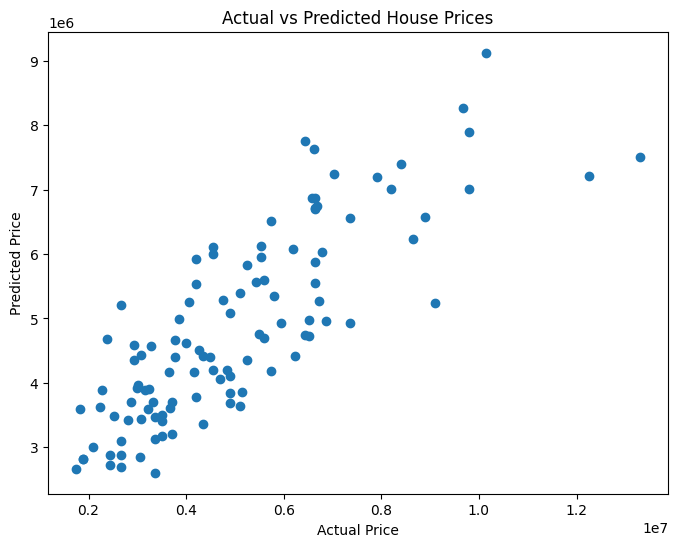

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

The scatter plot compares the actual and predicted house prices. Points closer to an imaginary 45° diagonal line indicate more accurate predictions, while points farther away represent larger prediction errors.

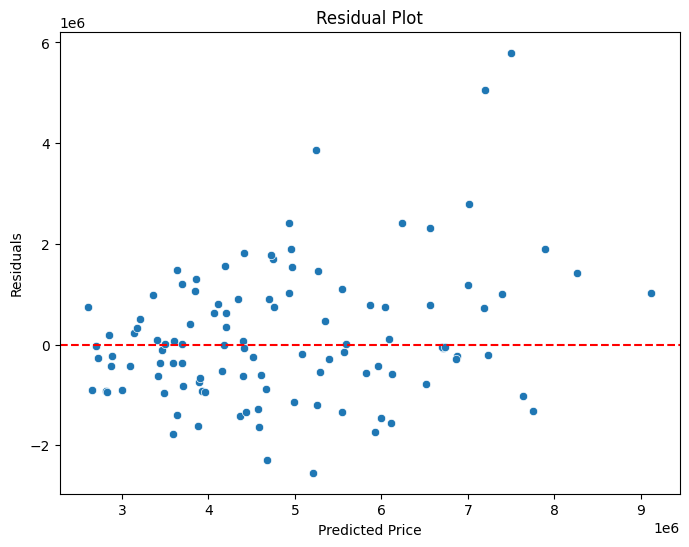

In [68]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

The residual plot shows the prediction errors of the model. A random scatter of points around the zero line indicates that the Linear Regression model has captured the relationship reasonably well.

## **Save The Model**

In [69]:
import os
import joblib

# Define the folder path
model_path = "/content/drive/MyDrive/House_Price_Prediction"

# Create the folder if it doesn't exist
os.makedirs(model_path, exist_ok=True)

# Save the trained model
joblib.dump(model, os.path.join(model_path, "house_price_model.pkl"))

print("Model saved successfully!")

Model saved successfully!
